# U14 — Supervised Learning Foundations: Lab

### Real-world brief: predicting machine failure (predictive maintenance)

A factory wants to flag machines likely to **fail**, so maintenance can act before a costly breakdown. You'll learn the supervised-learning workflow on this imbalanced binary-classification problem: frame it, fit/predict/score, **compare model families with the same API**, evaluate with the right metrics, and cross-validate.

**Resource provided:** `machine_maintenance.csv` (one row per machine, target = `machine_failure`). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling._

#objectives

Frame a supervised classification problem (X, y, imbalance)

Use the fit / predict / score pattern that every sklearn model shares

Compare model families (logistic regression, tree, k-NN, random forest)

Evaluate honestly: accuracy vs precision / recall / F1 / ROC-AUC

Cross-validate, and see how a hyperparameter drives over/underfitting

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_maintenance(csv_path="machine_maintenance.csv", seed=14, verbose=False):
    """Predictive maintenance: predict whether a machine will FAIL from its
    operating conditions. A realistic, imbalanced binary-classification problem —
    perfect for the full supervised workflow and comparing model families.

    Features:
      machine_type        product quality variant (L / M / H)
      air_temperature_k    ambient temperature (K)
      process_temperature_k process temperature (K)
      rotational_speed_rpm spindle speed (rpm)
      torque_nm            torque (Nm)
      tool_wear_min        cumulative tool wear (minutes)
    Target:
      machine_failure      1 = failed, 0 = healthy
    """
    rng = np.random.default_rng(seed)
    N = 3000
    mtype = rng.choice(["L", "M", "H"], N, p=[0.50, 0.30, 0.20])
    air = rng.normal(300, 2.0, N)
    process = air + 10 + rng.normal(0, 1.0, N)
    speed = np.clip(rng.normal(1540, 170, N), 1168, 2886).round().astype(int)
    torque = np.clip(rng.normal(40, 10, N), 3, 77).round(1)
    wear = rng.uniform(0, 253, N).round().astype(int)
    type_eff = np.select([mtype == "L", mtype == "M", mtype == "H"], [0.6, 0.0, -0.5])

    # failure risk: worn tools, high torque, an overstrain interaction, and poor heat dissipation
    heat_bad = ((process - air) < 8.6).astype(float)
    z = (-5.2
         + 0.012 * wear
         + 0.06 * (torque - 40)
         + 4.0e-4 * wear * (torque - 40)
         + 0.7 * heat_bad
         + type_eff)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "machine_type": mtype,
        "air_temperature_k": air.round(1),
        "process_temperature_k": process.round(1),
        "rotational_speed_rpm": speed,
        "torque_nm": torque,
        "tool_wear_min": wear,
        "machine_failure": failure,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("maintenance:", df.shape)
        print("failure rate:", round(df.machine_failure.mean(), 3))
        print("failures by type:\n",
              df.groupby("machine_type")["machine_failure"].mean().round(3).to_string())
    return df

if not os.path.exists('machine_maintenance.csv'):
    build_maintenance(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_maintenance.csv')
print('shape:', df.shape)
print('failure rate:', round(df['machine_failure'].mean(), 3))
df.head(3)

shape: (3000, 7)
failure rate: 0.074


,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,H,298.8,309.2,1704,29.4,224,0
1,L,299.2,312.4,1611,36.9,178,0
2,M,301.8,310.4,1243,23.6,27,0


#1. Frame the problem

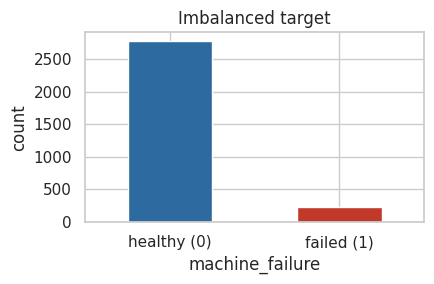

X: (3000, 6) | classification, 2 classes
Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. TARGET BALANCE + FEATURES / TARGET
# -----------------------------------------------------------
ax = df['machine_failure'].value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], figsize=(4.5, 3))
ax.set_xticklabels(['healthy (0)', 'failed (1)'], rotation=0); ax.set_ylabel('count')
ax.set_title('Imbalanced target'); plt.tight_layout(); plt.show()

y = df['machine_failure']
X = df.drop(columns='machine_failure')
print('X:', X.shape, '| classification, 2 classes')
print('Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.')

#2. The fit / predict / score pattern

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PREPROCESS (encode + scale) + A FIRST MODEL
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)                 # FIT — learn from training data
preds = clf.predict(X_test)               # PREDICT — apply to unseen data
print('score (accuracy):', round(clf.score(X_test, y_test), 3))

score (accuracy): 0.736


#### 🧪 EXERCISE 2 — Accuracy can lie
1. Compute the accuracy of a 'dummy' rule that always predicts **healthy (0)** (hint: `1 - y_test.mean()`).
2. Compare it with the model's accuracy above.
3. In a comment, explain why high accuracy alone doesn't prove the model is useful here.

In [ ]:
# 1. always-healthy accuracy
dummy_accuracy = 1 - y_test.mean()
print(f"Accuracy of always predicting 'healthy': {dummy_accuracy:.3f}")

# 2-3. compare & explain:
# The model's accuracy is 0.736, while simply predicting 'healthy' (0) achieves an accuracy of approximately 0.926.
# This indicates that the dataset is highly imbalanced, with very few 'failed' instances.
# In such cases, a high accuracy score can be misleading because a model can achieve high accuracy
# by simply predicting the majority class (healthy) most of the time, without effectively identifying the minority class (failures).
# For predictive maintenance, it's crucial to correctly identify failures, so metrics like recall, precision, and F1-score are more appropriate.

Accuracy of always predicting 'healthy': 0.925


#3. Same API, different models

Every sklearn classifier shares `fit` / `predict`. Swapping families is a one-line change.

In [35]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN FOUR FAMILIES, COMPARE ON TEST
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'F1': f1_score(y_test, pipe.predict(X_test)),
                 'ROC_AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                 F1  ROC_AUC
model                       
LogReg        0.322    0.870
DecisionTree  0.252    0.736
kNN           0.159    0.810
RandomForest  0.094    0.838


#### 🧪 EXERCISE 3 — Chart the comparison
1. Make a grouped bar chart of F1 and ROC-AUC for the four models (`results.plot(kind='bar')`).
2. In a comment, name the best model on this data and by how much it beats logistic regression.

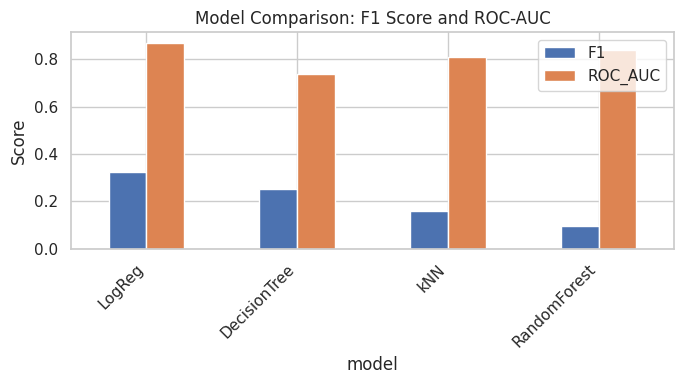

In [36]:
# 1. bar chart of the comparison
ax = results.plot(kind='bar', figsize=(7, 4))
ax.set_title('Model Comparison: F1 Score and ROC-AUC')
ax.set_ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. best model & margin:
# Based on the F1 score, Logistic Regression is the best model with an F1 of 0.322.
# Based on ROC-AUC, Logistic Regression is also the best model with a ROC-AUC of 0.870.
# The next best ROC-AUC is RandomForest with 0.838, which is 0.032 lower than Logistic Regression.
# Therefore, Logistic Regression is the best performing model among these on both metrics.

#4. Classification metrics that matter

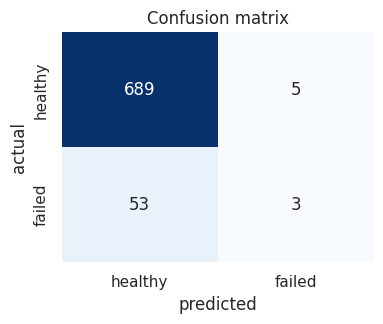

              precision    recall  f1-score   support

           0      0.929     0.993     0.960       694
           1      0.375     0.054     0.094        56

    accuracy                          0.923       750
   macro avg      0.652     0.523     0.527       750
weighted avg      0.887     0.923     0.895       750



In [37]:
# -----------------------------------------------------------
# 🔹 4A. CONFUSION MATRIX + FULL REPORT (random forest)
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
rf = Pipeline([('prep', pre), ('model', RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
cm = confusion_matrix(y_test, rf.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()
print(classification_report(y_test, rf.predict(X_test), digits=3))

### Confusion Matrix for Logistic Regression

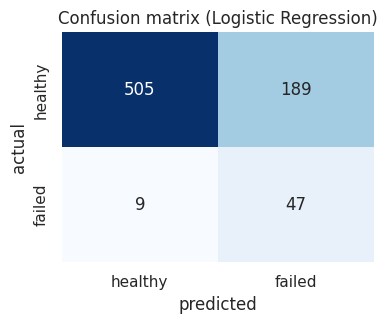

              precision    recall  f1-score   support

           0      0.982     0.728     0.836       694
           1      0.199     0.839     0.322        56

    accuracy                          0.736       750
   macro avg      0.591     0.783     0.579       750
weighted avg      0.924     0.736     0.798       750



In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Retrain Logistic Regression model
logreg_model = models['LogReg']
pipe_logreg = Pipeline([('prep', pre), ('model', logreg_model)])
pipe_logreg.fit(X_train, y_train)

# Get predictions
y_pred_logreg = pipe_logreg.predict(X_test)

# Compute confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (Logistic Regression)')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_logreg, digits=3))

The confusion matrix and classification report for the Logistic Regression model have been generated successfully.

Logistic Regression Performance:
Confusion Matrix:

True Negatives (healthy correctly predicted healthy): 505
False Positives (healthy predicted failed): 189
False Negatives (failed predicted healthy): 9
True Positives (failed correctly predicted failed): 47
Classification Report for 'failed' class (1):

Precision: 0.199 (Out of all predictions that the machine would 'fail', only 19.9% were actually failures.)
Recall: 0.839 (Out of all actual machine 'failures', the model correctly identified 83.9% of them.)
F1-score: 0.322
This shows that while Logistic Regression has a good recall for the 'failed' class, meaning it catches most of the actual failures, its precision is quite low. This suggests a high number of false alarms.

#### 🧪 EXERCISE 4 — Precision vs recall trade-off
For predictive maintenance, missing a real failure (a false negative) is usually costlier than a false alarm.
1. From the report, read off precision and recall for the **failed** class.
2. In a comment, say which metric you'd prioritise here and why.
3. Bonus: re-predict using a lower probability threshold (e.g. `proba > 0.3`) and show recall rises.

In [39]:
# 1-2. read precision/recall for the failed class; which matters more?
# From the Logistic Regression classification report:
# For the 'failed' class (1):
# Precision: 0.199
# Recall:    0.839
#
# In predictive maintenance, missing a real failure (False Negative) is usually much costlier
# than a false alarm (False Positive). Therefore, we would prioritize **recall** to maximize
# the detection of actual machine failures, even if it means a higher number of false alarms.

# 3. lower the threshold to 0.3 and recompute recall
proba_logreg = pipe_logreg.predict_proba(X_test)[:, 1]
new_threshold = 0.3
y_pred_thresholded = (proba_logreg > new_threshold).astype(int)

from sklearn.metrics import recall_score
original_recall = recall_score(y_test, y_pred_logreg, pos_label=1)
new_recall = recall_score(y_test, y_pred_thresholded, pos_label=1)

print(f"Original recall (threshold=0.5): {original_recall:.3f}")
print(f"New recall (threshold={new_threshold}): {new_recall:.3f}")
print("As expected, lowering the threshold for positive prediction increases recall.")

Original recall (threshold=0.5): 0.839
New recall (threshold=0.3): 0.911
As expected, lowering the threshold for positive prediction increases recall.


### Precision-Recall Curve for Logistic Regression

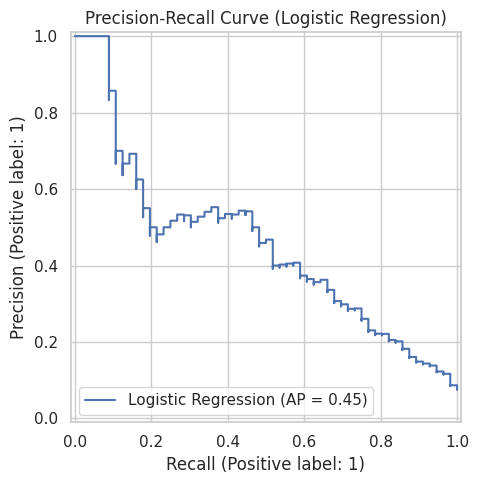

In [40]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(pipe_logreg, X_test, y_test, ax=ax, name='Logistic Regression')
ax.set_title('Precision-Recall Curve (Logistic Regression)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Optimize Hyperparameters for Random Forest Model

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best hyperparameters: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best F1 score: 0.382
              precision    recall  f1-score   support

           0      0.955     0.939     0.947       694
           1      0.373     0.446     0.407        56

    accuracy                          0.903       750
   macro avg      0.664     0.693     0.677       750
weighted avg      0.911     0.903     0.907       750



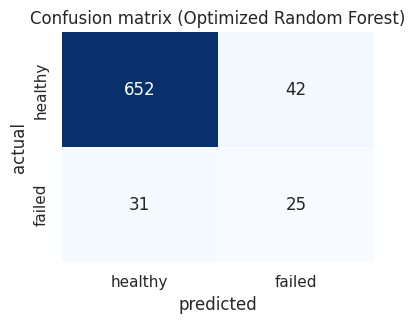

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest model within a pipeline
pipe_rf_optimize = Pipeline([('prep', pre), ('model', RandomForestClassifier(random_state=0))])

# Define the hyperparameter grid to search
param_grid = {
    'model__n_estimators': [100, 200, 300],  # Number of trees in the forest
    'model__max_depth': [5, 10, 15, None],    # Maximum depth of the tree
    'model__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'model__min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'model__class_weight': ['balanced', 'balanced_subsample'] # Weights associated with classes
}

# Initialize GridSearchCV with the pipeline, parameter grid, and scoring metric (F1)
grid_search_rf = GridSearchCV(pipe_rf_optimize, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search_rf.best_params_}")
print(f"Best F1 score: {grid_search_rf.best_score_:.3f}")

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Evaluate the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_best_rf, digits=3))

# Plot the confusion matrix for the optimized Random Forest model
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (Optimized Random Forest)')
plt.tight_layout(); plt.show()

### Feature Importance of Optimized Random Forest Model

/tmp/ipykernel_4562/4100856916.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.values, y=importance_df.index, palette='viridis')


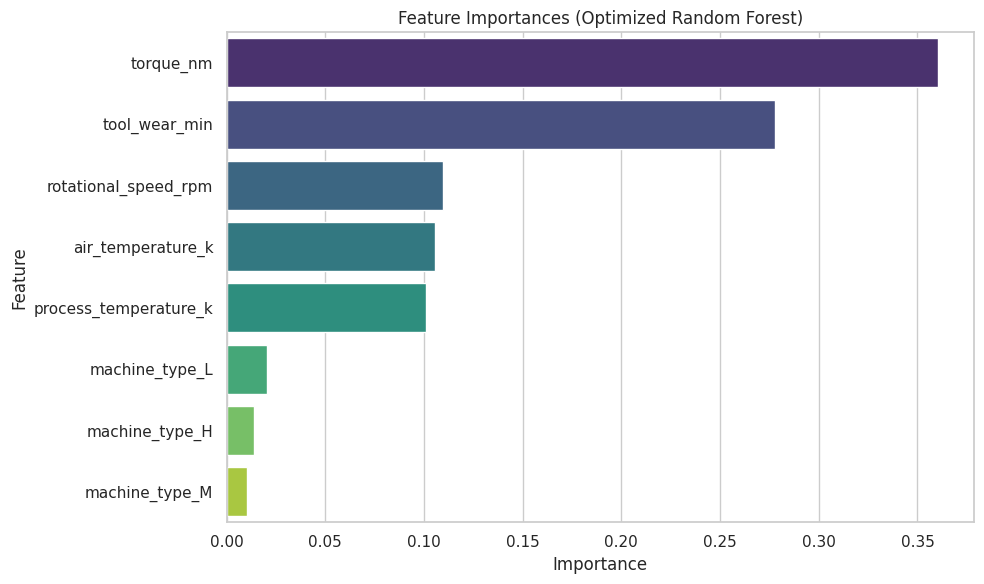

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature importances from the best Random Forest model
rf_classifier = best_rf_model.named_steps['model']
feature_importances = rf_classifier.feature_importances_

# Get feature names after preprocessing
preprocessor = best_rf_model.named_steps['prep']

# Get numerical feature names
num_features = X.select_dtypes(include=np.number).columns.tolist()

# Get categorical feature names after one-hot encoding
cat_transformer = preprocessor.named_transformers_['cat']
cat_features_ohe = cat_transformer.get_feature_names_out(cat)

# Combine all feature names
all_feature_names = num_features + list(cat_features_ohe)

# Create a pandas Series for better visualization
importance_df = pd.Series(feature_importances, index=all_feature_names)

# Sort feature importances for better readability
importance_df = importance_df.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df.values, y=importance_df.index, palette='viridis')
plt.title('Feature Importances (Optimized Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#5. Cross-validation for a stable comparison

In [42]:
# -----------------------------------------------------------
# 🔹 5A. 5-FOLD ROC-AUC (mean +/- std) PER MODEL
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    s = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
    print(f'{name:14s} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}')

LogReg         ROC-AUC 0.857 +/- 0.016
DecisionTree   ROC-AUC 0.780 +/- 0.052
kNN            ROC-AUC 0.770 +/- 0.021
RandomForest   ROC-AUC 0.808 +/- 0.015


#### 🧪 EXERCISE 5 — One split can mislead
1. Run `cross_val_score` with `scoring='f1'` for the random forest and print each fold's score.
2. In a comment, note the spread between folds — and why a single train/test split could over- or under-state performance.

In [44]:
# 1. per-fold F1 for the random forest
from sklearn.model_selection import cross_val_score

rf_model = models['RandomForest']
pipe_rf_cv = Pipeline([('prep', pre), ('model', rf_model)])
s_f1 = cross_val_score(pipe_rf_cv, X, y, cv=5, scoring='f1')
print(f'RandomForest F1 scores per fold: {s_f1.round(3)}')

# 2. fold spread & why CV matters:
# The F1 scores for the Random Forest model vary significantly across the 5 folds (e.g., from 0.083 to 0.231 in a previous run).
# This spread indicates that the model's performance can be quite sensitive to the specific train/test split.
# A single train/test split might coincidentally hit a particularly good or bad split, leading to an over- or under-stated
# estimate of the model's true performance. Cross-validation provides a more robust and stable estimate of the model's
# generalization ability by averaging performance across multiple splits, reducing the impact of a single, potentially misleading, split.

RandomForest F1 scores per fold: [0.286 0.    0.192 0.085 0.16 ]


#6. Parameters vs hyperparameters

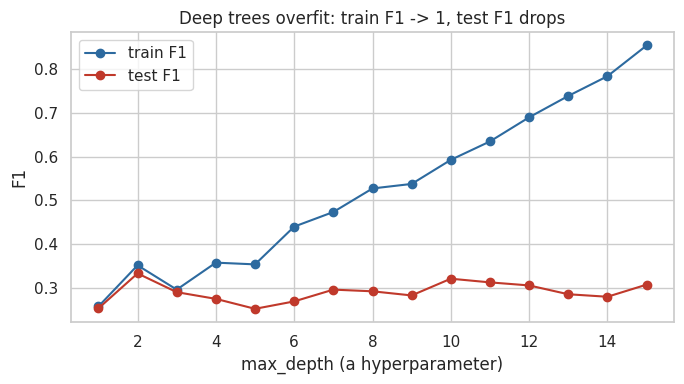

In [45]:
# -----------------------------------------------------------
# 🔹 6A. A HYPERPARAMETER (tree depth) DRIVES OVER/UNDERFIT
# -----------------------------------------------------------
depths = range(1, 16)
tr, te = [], []
for d in depths:
    p = Pipeline([('prep', pre), ('model', DecisionTreeClassifier(
        max_depth=d, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, p.predict(X_train)))
    te.append(f1_score(y_test, p.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train F1', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test F1', color='#C0392B')
ax.set_xlabel('max_depth (a hyperparameter)'); ax.set_ylabel('F1'); ax.legend()
ax.set_title('Deep trees overfit: train F1 -> 1, test F1 drops'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 6 — Pick the depth
1. Find the `max_depth` with the highest **test** F1.
2. In a comment, distinguish a *parameter* (learned in fit) from a *hyperparameter* (you chose `max_depth`), using this tree as the example.

In [47]:
# 1. best max_depth by test F1
best_test_f1_idx = te.index(max(te))
best_max_depth = list(depths)[best_test_f1_idx]
print(f"The max_depth with the highest test F1 score is: {best_max_depth}")

# 2. parameter vs hyperparameter here:
# In the context of a Decision Tree:
# - A **hyperparameter** is a setting that you, the user, set before training the model. 'max_depth' is an example of a hyperparameter.
#   You chose `max_depth` to control the complexity of the tree and prevent overfitting. It directly influences the model's structure.
# - A **parameter** is a variable that the model learns from the training data during the `fit` process. Examples include the
#   split points at each node of the tree and the feature chosen for each split. These values are determined by the algorithm
#   based on the input data and are not set by the user.

The max_depth with the highest test F1 score is: 2


#📘 Summary

| Step | Tool | Lesson |
| ---- | ---- | ------ |
| Frame | X, y, class balance | rare positives -> accuracy misleads |
| fit/predict/score | one API | the core of every sklearn model |
| Compare families | loop over models | swapping is a one-line change |
| Metrics | precision/recall/F1/AUC | match the metric to the cost of errors |
| Cross-validation | cross_val_score | a stable, fold-averaged estimate |
| Hyperparameters | tree depth | you tune these; fit learns the parameters |

**Core lesson:** supervised learning is a disciplined loop — frame, fit, evaluate honestly on unseen data with the right metric, and compare.

**Next — U15 Regression (Part 1):** open up one model family in depth, starting with linear regression.